# Evaluating Agents Using EDD
---

## Evaluation-Driven Development (EDD) 

### Overview

This project is used to create and evalate `spans` related to Agent `traces`.


<img src="images/agent_dark_background.png" width="500"/>

### Import libraries

In [ ]:
from openai import OpenAI
import pandas as pd
import os
import json
import duckdb
import logging
from pydantic import BaseModel, Field
from IPython.display import Markdown
from typing import Any, Dict, List, Sequence, Union
from dotenv import load_dotenv

### Initialize OpenAI Client|

In [ ]:
load_dotenv() 
API_KEY = os.getenv("OPENAI_API_KEY")
client = OpenAI(api_key=API_KEY)

MODEL = "gpt-4o-mini"

###

## Defining Agent Tools

### Database Lookup Tool

Read local parquet file containing transaction data. 


In [ ]:
# define the path to the transactional data
TRANSACTION_DATA_FILE_PATH = 'data/Store_Sales_Price_Elasticity_Promotions_Data.parquet'

The database look up tool works in a three-step process:

1. **Prepare Database** – create SQL table from local file (if not already done).

2. **Generate SQL** – translate user prompt into SQL via LLM.

3. **Execute SQL** – run the SQL query against the database and return results.

<img src="images/database_lookup_tool_dark.png" width="500"/>


**Prompt Template**

In [ ]:
SQL_GENERATION_PROMPT = """
Generate an SQL query based on the prompt that follows. Do not reply with anything besides the SQL query.
The prompt is: {prompt}

The available columns are: {columns}
The table name is: {table_name}
"""

**Helper Functions**

In [ ]:
def generate_sql_query(prompt: str, columns: list[str], table_name: str) -> str:
    """
    Generate a valid SQL query from a natural language prompt.

    Parameters
    ----------
    prompt : str
        Natural language query.
    columns : list[str]
        Column names in the target table.
    table_name : str
        Name of the table to query.

    Returns
    -------
    str
        Generated SQL query string.
    """
    formatted_prompt = SQL_GENERATION_PROMPT.format(
        prompt=prompt,
        columns=columns,
        table_name=table_name
    )

    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": formatted_prompt}],
    )

    return response.choices[0].message.content.strip()


In [ ]:
def lookup_sales_data(prompt: str) -> str:
    """
    Query sales data from a Parquet file using LLM-generated SQL.

    Parameters
    ----------
    prompt : str
        Natural language query.

    Returns
    -------
    str
        Query result as formatted text or an error message.
    """
    try:
        table_name = "sales"

        # Step 1: Load Parquet into DuckDB
        df = pd.read_parquet(TRANSACTION_DATA_FILE_PATH)
        duckdb.sql(f"CREATE TABLE IF NOT EXISTS {table_name} AS SELECT * FROM df")

        # Step 2: Generate SQL and clean output
        sql_query = generate_sql_query(prompt, df.columns.tolist(), table_name)
        sql_query = sql_query.strip().replace("```sql", "").replace("```", "")

        # Step 3: Execute SQL and return results
        result = duckdb.sql(sql_query).df()
        return result.to_string()

    except Exception as e:
        return f"Error accessing data: {e}"


**Test Tool Functioning**

In [ ]:
#template = OG_SQL_GENERATION_PROMPT
prompt = "Show me all the sales for store 1320 on November 1st, 2021"

example_data = lookup_sales_data(prompt)
print(example_data)

    Store_Number  SKU_Coded  Product_Class_Code  Sold_Date  Qty_Sold  Total_Sale_Value  On_Promo
0           1320    6173050               22875 2021-11-01         1          4.990000         0
1           1320    6174250               22875 2021-11-01         1          0.890000         0
2           1320    6176200               22975 2021-11-01         2         99.980003         0
3           1320    6176800               22800 2021-11-01         1         14.970000         0
4           1320    6177250               22975 2021-11-01         1          6.890000         0
5           1320    6177300               22800 2021-11-01         1          9.990000         0
6           1320    6177350               22800 2021-11-01         2         16.980000         0
7           1320    6177700               22875 2021-11-01         1          3.190000         0
8           1320    6178000               22875 2021-11-01         2          6.380000         0
9           1320    6178250   

### Data Analysis Tool

In [ ]:
DATA_ANALYSIS_PROMPT = """
Analyze the following data: {data}
Your job is to answer the following question: {prompt}
"""

In [ ]:
def analyze_sales_data(prompt: str, data: str) -> str:
    """
    Generate an AI-based sales data analysis.

    Formats a prompt using the provided template, data, and instruction,
    then queries a chat-based LLM for an analytical response.

    Args:
        prompt (str): Instruction describing the analysis task.
        data (str): Sales dataset or text input to analyze.

    Returns:
        str: LLM-generated analysis, or a fallback message if empty.
    """
    formatted_prompt = DATA_ANALYSIS_PROMPT.format(data=data, prompt=prompt)

    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": formatted_prompt}],
    )

    analysis = response.choices[0].message.content
    return analysis if analysis else "No analysis could be generated"

In [ ]:
#template = OG_DATA_ANALYSIS_PROMPT
prompt = "What are some key business insights in the data?"

insights = analyze_sales_data(prompt, example_data)
display(insights)

'Based on the provided sales data from Store 1320 for a specific date (November 1, 2021), here are some key business insights:\n\n### Summary of Sales Performance\n1. **Total Sales and Quantity Sold**:\n   - The total quantity sold across all SKUs is calculated by summing the `Qty_Sold` column.\n   - The total sales value can be derived by summing the `Total_Sale_Value` column.\n   - This will provide insights into total revenue generated on that specific date.\n\n2. **Product Class Insights**:\n   - The data includes various product class codes (e.g., 22800, 22975, 24400, etc.). Analyzing the sales figures per product class can help identify which class is the best-selling and contributes the most to revenue.\n   - Product class 22975 appears to be frequently represented, indicating it may be a popular category.\n\n### Promotion Effectiveness\n3. **Impact of Promotions**:\n   - Only one item (`SKU 6195800` with `On_Promo = 1`) was sold on promotion, and it sold three units. The potent

### Data Visualization Tool

**Step 1:** Create chart configuration: chart type, title, data, labels for x-axis and y-axis (Using an LLM call)

In [ ]:
CHART_CONFIGURATION_PROMPT = """
Generate a chart configuration based on this data: {data}
The goal is to show: {visualization_goal}
"""

In [ ]:
class VisualizationConfig(BaseModel):
    """
    Configuration schema for chart generation.

    Defines parameters for creating visualizations,
    including chart type, axes, and title.
    """
    chart_type: str = Field(..., description="Type of chart to generate (e.g., bar, line, scatter).")
    x_axis: str = Field(..., description="Column name for the x-axis.")
    y_axis: str = Field(..., description="Column name for the y-axis.")
    title: str = Field(..., description="Chart title.")

In [ ]:
def extract_chart_config(data: str, visualization_goal: str) -> dict:
    """Generate chart visualization configuration
    
    Args:
        data: String containing the data to visualize
        visualization_goal: Description of what the visualization should show
        
    Returns:
        Dictionary containing line chart configuration
    """
    formatted_prompt = CHART_CONFIGURATION_PROMPT.format(data=data,
                                                  visualization_goal=visualization_goal)
    
    response = client.beta.chat.completions.parse(
        model=MODEL,
        messages=[{"role": "user", "content": formatted_prompt}],
        response_format=VisualizationConfig,
    )
    
    try:
        # Extract axis and title info from response
        content = response.choices[0].message.content
        
        # Return structured chart config
        return {
            "chart_type": content.chart_type,
            "x_axis": content.x_axis,
            "y_axis": content.y_axis,
            "title": content.title,
            "data": data
        }
    except Exception:
        return {
            "chart_type": "bar", 
            "x_axis": "date",
            "y_axis": "value",
            "title": visualization_goal,
            "data": data
        }

**Step 2:** Generate Python code based on configuration generated on step 1 (Using an LLM call)

In [ ]:
CREATE_CHART_PROMPT = """
    Write python code to create a chart based on the configuration that follows.
    Only return the code, for the month of Novemeber, no other text.
    config: {config}
"""

In [ ]:
def create_chart(config: dict) -> str:
    """
    Generate Python code for a chart based on the given configuration.

    Args:
        config (dict): Chart parameters including type, axes, and title.

    Returns:
        str: Python code string for rendering the chart.
    """
    formatted_prompt = CREATE_CHART_PROMPT.format(config=config)

    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": formatted_prompt}],
    )

    code = response.choices[0].message.content
    code = code.replace("```python", "").replace("```", "")
    code = code.strip()

    return code


In [ ]:
def generate_visualization(data: str, visualization_goal: str) -> str:
    """
    Generate Python code for a visualization based on input data and goal.

    Args:
        data (str): Dataset or structured text to visualize.
        visualization_goal (str): Description of the intended visualization.

    Returns:
        str: Python code that creates the requested visualization.
    """
    config = extract_chart_config(data, visualization_goal)
    code = create_chart(config)
    return code

In [ ]:
visualization_goal = "A bar chart of sales by SKU. Put the SKU_Coded on the x-axis and the sales on the y-axis."

viz_code = generate_visualization(example_data, visualization_goal)
print(viz_code)

import pandas as pd
import matplotlib.pyplot as plt

data = {
    'Store_Number': [1320]*30,
    'SKU_Coded': [6173050, 6174250, 6176200, 6176800, 6177250, 6177300, 6177350, 6177700, 6178000, 6178250, 
                  6179250, 6179300, 6179400, 6179450, 6179500, 6179750, 6180550, 6182050, 6183750, 
                  6184100, 6188550, 6190050, 6190150, 6190200, 6190250, 6190350, 6190400, 6193750, 
                  6195350, 6195800],
    'Product_Class_Code': [22875, 22875, 22975, 22800, 22975, 22800, 22800, 22875, 22875, 22800, 
                           24400, 22800, 24400, 24400, 24400, 22800, 22975, 22975, 22850, 22975, 
                           22950, 24425, 24425, 24425, 24425, 22950, 22950, 22875, 24375, 22850],
    'Sold_Date': ['2021-11-01']*30,
    'Qty_Sold': [1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 2, 2, 1, 1, 2, 1, 1, 3, 3, 2, 5, 1, 1, 1, 
                 1, 1, 1, 1, 3],
    'Total_Sale_Value': [4.99, 0.89, 99.98, 14.97, 6.89, 9.99, 16.98, 3.19, 6.38, 16.59, 
               

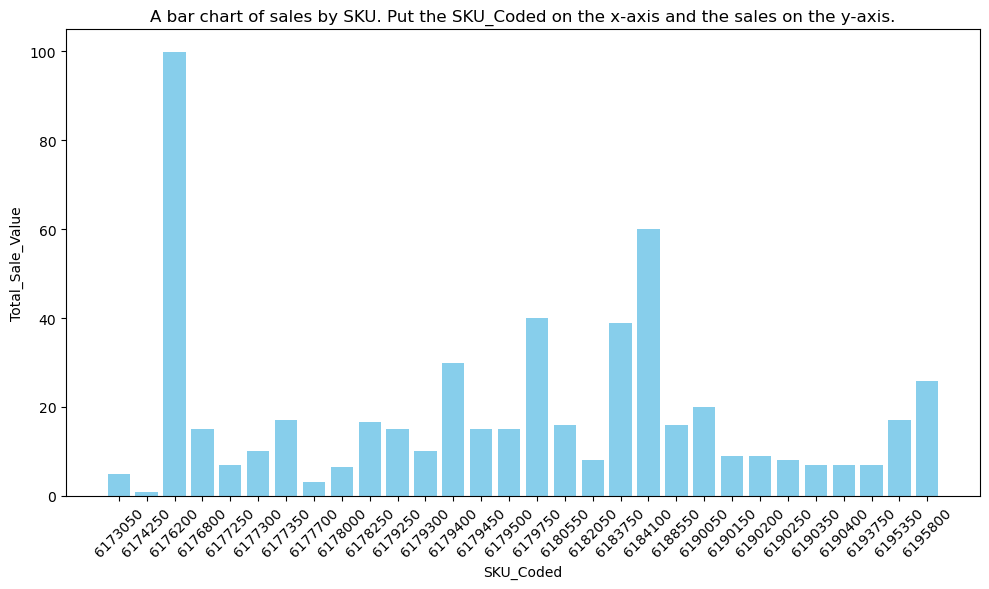

In [ ]:
# visualize
exec(viz_code)

## Defining the Router

### Router Schema    

Now that all skills (tools) have been defined, we move to creating the router. The router will take the original user input and act as the planner. The router will also be responsible for calling tools. After each tool call is completed, the router will evaluate if additional tools should be called. 

In [ ]:
# Define tools/functions that can be called by the model
tools = [
    {
        "type": "function",
        "function": {
            "name": "lookup_sales_data",
            "description": "Look up data from Store Sales Price Elasticity Promotions dataset",
            "parameters": {
                "type": "object",
                "properties": {
                    "prompt": {"type": "string", "description": "The unchanged prompt that the user provided."}
                },
                "required": ["prompt"]
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "analyze_sales_data", 
            "description": "Analyze sales data to extract insights",
            "parameters": {
                "type": "object",
                "properties": {
                    "data": {"type": "string", "description": "The lookup_sales_data tool's output."},
                    "prompt": {"type": "string", "description": "The unchanged prompt that the user provided."}
                },
                "required": ["data", "prompt"]
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "generate_visualization",
            "description": "Generate Python code to create data visualizations",
            "parameters": {
                "type": "object", 
                "properties": {
                    "data": {"type": "string", "description": "The lookup_sales_data tool's output."},
                    "visualization_goal": {"type": "string", "description": "The goal of the visualization."}
                },
                "required": ["data", "visualization_goal"]
            }
        }
    }
]

# Dictionary mapping function names to their implementations
tool_implementations = {
    "lookup_sales_data": lookup_sales_data,
    "analyze_sales_data": analyze_sales_data, 
    "generate_visualization": generate_visualization
}

### Router Logic

The router is composed of a tool calling method and a main loop that runs until the router has completed a trace. 

<img src="images/agent_dark_background.png" width="500"/>

In [ ]:
SYSTEM_PROMPT = """
You are a helpful assistant that can answer questions about the Store Sales Price Elasticity Promotions dataset.
"""

In [ ]:
# code for executing the tools returned in the model's response
def handle_tool_calls(tool_calls, messages):
    
    for tool_call in tool_calls:   
        function = tool_implementations[tool_call.function.name]
        function_args = json.loads(tool_call.function.arguments)
        result = function(**function_args)
        messages.append({"role": "tool", "content": result, "tool_call_id": tool_call.id})
        
    return messages

In [ ]:
def run_agent(system_prompt, messages):
    print("Running agent with messages:", messages)

    if isinstance(messages, str):
        messages = [{"role": "user", "content": messages}]
        
    # Check and add system prompt if needed
    if not any(
            isinstance(message, dict) and message.get("role") == "system" for message in messages
        ):
            sys_prompt = {"role": "system", "content": system_prompt}
            messages.append(sys_prompt)

    while True:
        print("Making router call to OpenAI")
        response = client.chat.completions.create(
            model=MODEL,
            messages=messages,
            tools=tools,
        )
        messages.append(response.choices[0].message)
        tool_calls = response.choices[0].message.tool_calls
        print("Received response with tool calls:", bool(tool_calls))

        # if the model decides to call function(s), call handle_tool_calls
        if tool_calls:
            print("Processing tool calls")
            messages = handle_tool_calls(tool_calls, messages)
        else:
            print("No tool calls, returning final response")
            return response.choices[0].message.content

In [ ]:
system_prompt = SYSTEM_PROMPT
user_question = "Show me the code for a scatterplot graph of sales by store in Nov 2021, and tell me what trends you see."

results = run_agent(system_prompt, user_question)

Running agent with messages: Show me the code for a scatterplot graph of sales by store in Nov 2021, and tell me what trends you see.
Making router call to OpenAI
Received response with tool calls: True
Processing tool calls
Making router call to OpenAI
Received response with tool calls: True
Processing tool calls
Making router call to OpenAI
Received response with tool calls: True
Processing tool calls
Making router call to OpenAI
Received response with tool calls: False
No tool calls, returning final response


In [ ]:
Markdown(results)

Here's the Python code to create a scatter plot of total sales by store for November 2021:

```python
import pandas as pd
import matplotlib.pyplot as plt

# Creating dataframe from the provided data
data = {
    "Store_Number": [330, 550, 660, 770, 880, 990, 1100, 1210, 1320, 1540, 
                     1650, 1760, 1870, 1980, 2090, 2200, 2310, 2420,
                     2530, 2640, 2750, 2970, 3080, 3190, 3300, 3410,
                     3630, 3740, 4070, 4180, 4400, 4730, 4840],
    "Total_Qty_Sold": [1105.0, 764.0, 1208.0, 973.0, 1525.0, 1280.0, 1712.0,
                       1821.0, 1701.0, 1801.0, 1770.0, 1207.0, 1648.0, 
                       893.0, 1080.0, 1513.0, 1594.0, 1370.0, 890.0,
                       1005.0, 1462.0, 2312.0, 1454.0, 1003.0, 1859.0, 
                       1345.0, 1311.0, 949.0, 932.0, 913.0, 225.0, 
                       819.0, 1612.0],
    "Total_Sale_Value": [12569.599911, 9554.049975, 13041.239901, 9181.769959, 17753.769956,
                         15101.459945, 19298.679917, 21021.669984, 19553.789981,
                         21207.689942, 23186.909958, 14598.209948, 17091.849894,
                         9084.959929, 11617.179888, 16854.439921, 16611.539945,
                         15234.709888, 11139.740003, 10891.639931, 16310.409961,
                         31000.569969, 18044.450005, 11934.999961, 23730.719905,
                         15982.159946, 14202.299958, 10719.049952, 9161.409921,
                         10213.819920, 4390.689987, 10571.779962, 19127.169971]
}

df = pd.DataFrame(data)

# Creating the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['Store_Number'], df['Total_Sale_Value'], color='blue')
plt.title('Scatterplot of Sales by Store (Nov 2021)')
plt.xlabel('Store Number')
plt.ylabel('Total Sale Value')
plt.grid(alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
```

### Trends Observed:

1. **Overall Increase**: There is a general upward trend in total sales value as the store numbers increase, suggesting that larger store numbers tend to have higher sales values.

2. **Outlier Detection**: Store number **2970** shows a notably high total sale value compared to others, which may warrant further investigation as an outlier.

3. **Fluctuations in Intermediate Stores**: Some stores with intermediate numbers (like **Store 330** and **Store 550**) have lower sales, indicating variance in performance across the stores.

4. **Clustering of Values**: Many stores cluster around certain sale values, particularly between **10,000** to **22,000**, indicating that this might be a common performance range.

5. **Low Sales Stores**: **Store 4400** has exceptionally low sales, which deviates from the overall trend and might indicate a need for strategic adjustments.

These trends can help identify which stores are performing well and which may require management attention. Understanding these patterns is essential for forecasting and inventory management in future sales periods.

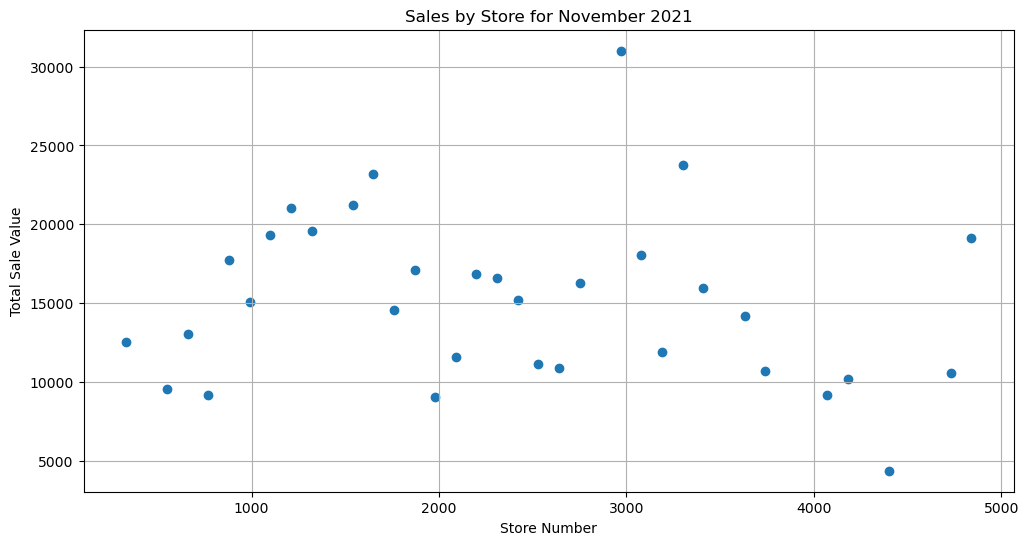

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

# Data for sales by store
data_string = """Store_Number,Total_Qty_Sold,Total_Sale_Value
990,1280.0,15101.459945
880,1525.0,17753.769956
2420,1370.0,15234.709888
2640,1005.0,10891.639931
2090,1080.0,11617.179888
4840,1612.0,19127.169971
3080,1454.0,18044.450005
4070,932.0,9161.409921
2750,1462.0,16310.409961
1980,893.0,9084.959929
3740,949.0,10719.049952
1100,1712.0,19298.679917
3190,1003.0,11934.999961
3410,1345.0,15982.159946
3300,1859.0,23730.719905
660,1208.0,13041.239901
770,973.0,9181.769959
2970,2312.0,31000.569969
2530,890.0,11139.740003
4400,225.0,4390.689987
1210,1821.0,21021.669984
1760,1207.0,14598.209948
330,1105.0,12569.599911
1320,1701.0,19553.789981
1540,1801.0,21207.689942
4730,819.0,10571.779962
2200,1513.0,16854.439921
2310,1594.0,16611.539945
1870,1648.0,17091.849894
3630,1311.0,14202.299958
4180,913.0,10213.819920
550,764.0,9554.049975
1650,1770.0,23186.909958
"""

# Prepare the data
data = pd.read_csv(StringIO(data_string))

# Creating the line chart
plt.figure(figsize=(12, 6))
plt.scatter(data['Store_Number'], data['Total_Sale_Value'])
plt.title('Sales by Store for November 2021')
plt.xlabel('Store Number')
plt.ylabel('Total Sale Value')
plt.grid()

# Show the chart
plt.show()

## Improving the System
---

In [ ]:
IMP_SQL_GENERATION_PROMPT = """
    You are an expert SQL developer. Your task is to generate a syntactically valid SQL query 
    that answers the user’s request based on the provided table schema. 
    You must return **only** the SQL code, formatted cleanly with uppercase SQL keywords.

    Follow these steps internally before producing the final answer:
    1. Analyze the user’s intent.
    2. Identify which columns and filters are relevant.
    3. Construct a valid SQL SELECT statement that answers the query.

    Schema Information:
    - Table Name: {table_name}
    - Available Columns: {columns}

    User Request:
    "{prompt}"

    Guidelines:
    - Return only the SQL query (no explanations, comments, or markdown).
    - Use exact column names as provided — do not invent or rename any.
    - Prefer simple, interpretable SQL (avoid unnecessary nesting or joins).
    - If the user request is ambiguous or impossible, return:
      SELECT "ERROR: Ambiguous or Unsupported Query" AS message;
"""